# Q2-1
If we want to train a model by these 4 txt files. The first step is construct a matrxi with features and label. 
Then we use this matrix to train random forest model and tuning.

In [1]:
import numpy as np
from scipy.sparse import coo_matrix
from sklearn.preprocessing import LabelEncoder

In [2]:
# load wordlist
wordlist_path = "/Users/mengchuishuo/Desktop/5054/HW4/20newsgroup/wordlist.txt"
with open(wordlist_path, "r") as f:
    words = [line.strip() for line in f.readlines()]
print("Loaded keywords:", len(words))

Loaded keywords: 100


In [3]:
# load labels
labels_path = "/Users/mengchuishuo/Desktop/5054/HW4/20newsgroup/newsgroups.txt"
with open(labels_path, "r") as f:
    labels_raw = [line.strip() for line in f.readlines()]

In [4]:
# the raw labels are 1, 2, 3, 4
# now we should convert to 0, 1, 2, 3
le = LabelEncoder()
y = le.fit_transform(labels_raw) # this is labels
print("Loaded labels:", len(y))

Loaded labels: 16242


In [5]:
# load documents
docs_path = "/Users/mengchuishuo/Desktop/5054/HW4/20newsgroup/documents.txt"

rows = []
cols = []
with open(docs_path, "r") as f:
    for line in f:
        doc_id, word_id, value = line.strip().split()
        rows.append(int(doc_id) - 1)   # convert to 0-index
        cols.append(int(word_id) - 1)

# all non-zero values are 1
data = np.ones(len(rows))

In [6]:
# build sparse matrix X
n_docs = len(y)          # 16242
n_words = len(words)     # 100

X = coo_matrix((data, (rows, cols)), shape=(n_docs, n_words)).tocsr() # this is X
print("X shape:", X.shape)
print("Matrix density:", X.nnz / (n_docs * n_words))

X shape: (16242, 100)
Matrix density: 0.04029737717029922


Now, we have the data X and y. We start to train random forest and tuning

In [7]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [8]:
print("Data loaded:")
print("X shape =", X.shape)
print("y shape =", y.shape)

# 100 key words across 16,242 postings
# 4 labels

Data loaded:
X shape = (16242, 100)
y shape = (16242,)


In [9]:
# define the parameter we want to tuning
n_estimators_list = [50, 100, 200, 300]  # how many trees
max_features_list = [5, 10, 20, 30, "sqrt", "log2"] # how many predictors

In [10]:
# start to tuning by 5-CV
best_score = 0
best_params = None
best_model = None

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

for n in n_estimators_list:
    for mf in max_features_list:

        model = RandomForestClassifier(
            n_estimators=n,
            max_features=mf,
            random_state=42,
            n_jobs=-1
        )

        scores = cross_val_score(model, X, y, cv=kfold, n_jobs=-1)

        mean_acc = scores.mean()
        print(f"n_estimators={n}, max_features={mf}, CV acc={mean_acc:.4f}")

        if mean_acc > best_score:
            best_score = mean_acc
            best_params = (n, mf)
            best_model = model

n_estimators=50, max_features=5, CV acc=0.8117
n_estimators=50, max_features=10, CV acc=0.8090
n_estimators=50, max_features=20, CV acc=0.8043
n_estimators=50, max_features=30, CV acc=0.7999
n_estimators=50, max_features=sqrt, CV acc=0.8090
n_estimators=50, max_features=log2, CV acc=0.8090
n_estimators=100, max_features=5, CV acc=0.8139
n_estimators=100, max_features=10, CV acc=0.8086
n_estimators=100, max_features=20, CV acc=0.8040
n_estimators=100, max_features=30, CV acc=0.8002
n_estimators=100, max_features=sqrt, CV acc=0.8086
n_estimators=100, max_features=log2, CV acc=0.8118
n_estimators=200, max_features=5, CV acc=0.8131
n_estimators=200, max_features=10, CV acc=0.8086
n_estimators=200, max_features=20, CV acc=0.8034
n_estimators=200, max_features=30, CV acc=0.7992
n_estimators=200, max_features=sqrt, CV acc=0.8086
n_estimators=200, max_features=log2, CV acc=0.8118
n_estimators=300, max_features=5, CV acc=0.8134
n_estimators=300, max_features=10, CV acc=0.8094
n_estimators=300, 

In [11]:
# Report the best CV error, the corresponding confusion matrix and tuning parameters
best_model.fit(X, y)

y_pred = best_model.predict(X)
conf_mat = confusion_matrix(y, y_pred)

print("\n==============================")
print(" BEST CROSS-VALIDATION RESULT ")
print("==============================")
print(f"Best CV accuracy = {best_score:.4f}")
print(f"Best CV error    = {1 - best_score:.4f}")
print(f"Best parameters: n_estimators={best_params[0]}, max_features={best_params[1]}")
print("\nConfusion Matrix (training set):")
print(conf_mat)


 BEST CROSS-VALIDATION RESULT 
Best CV accuracy = 0.8139
Best CV error    = 0.1861
Best parameters: n_estimators=100, max_features=5

Confusion Matrix (training set):
[[4360   85   86   74]
 [ 201 3097   89  132]
 [ 260   96 2141  160]
 [ 146  130   99 5086]]



Top 10 important keywords:
1. windows (importance=0.04173)
2. christian (importance=0.03478)
3. god (importance=0.03202)
4. car (importance=0.03177)
5. government (importance=0.02790)
6. team (importance=0.02376)
7. jews (importance=0.02286)
8. graphics (importance=0.02062)
9. space (importance=0.01834)
10. religion (importance=0.01794)


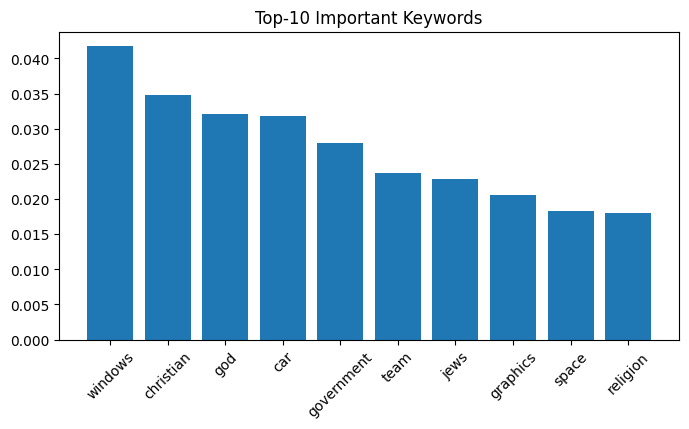

In [12]:
# the ten most important keywords based on variable importance
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1][:10]  # top 10

print("\nTop 10 important keywords:")
for rank, idx in enumerate(indices, 1):
    print(f"{rank}. {words[idx]} (importance={importances[idx]:.5f})")

    
plt.figure(figsize=(8, 4))
plt.bar(range(10), importances[indices])
plt.xticks(range(10), [words[i] for i in indices], rotation=45)
plt.title("Top-10 Important Keywords")
plt.show()

# Q2-2

In [13]:
n_estimators_list = [50, 100, 150, 200]     # number of trees
learning_rate_list = [0.05, 0.1, 0.2]       # learning rate
max_depth_list = [2, 3, 4]                  # tree depth

In [14]:
best_score = 0
best_params = None
best_model = None

kfold = KFold(n_splits=5, shuffle=True, random_state=42)


from sklearn.ensemble import GradientBoostingClassifier

for n in n_estimators_list:
    for lr in learning_rate_list:
        for depth in max_depth_list:

            model = GradientBoostingClassifier(
                n_estimators=n,
                learning_rate=lr,
                max_depth=depth,
                random_state=42
            )

            scores = cross_val_score(model, X, y, cv=kfold, n_jobs=-1)
            mean_acc = scores.mean()

            print(f"n_estimators={n}, lr={lr}, depth={depth} → CV acc={mean_acc:.4f}")

            if mean_acc > best_score:
                best_score = mean_acc
                best_params = (n, lr, depth)
                best_model = model

n_estimators=50, lr=0.05, depth=2 → CV acc=0.7198
n_estimators=50, lr=0.05, depth=3 → CV acc=0.7531
n_estimators=50, lr=0.05, depth=4 → CV acc=0.7713
n_estimators=50, lr=0.1, depth=2 → CV acc=0.7709
n_estimators=50, lr=0.1, depth=3 → CV acc=0.7934
n_estimators=50, lr=0.1, depth=4 → CV acc=0.8043
n_estimators=50, lr=0.2, depth=2 → CV acc=0.8011
n_estimators=50, lr=0.2, depth=3 → CV acc=0.8117
n_estimators=50, lr=0.2, depth=4 → CV acc=0.8157
n_estimators=100, lr=0.05, depth=2 → CV acc=0.7713
n_estimators=100, lr=0.05, depth=3 → CV acc=0.7915
n_estimators=100, lr=0.05, depth=4 → CV acc=0.8042
n_estimators=100, lr=0.1, depth=2 → CV acc=0.7989
n_estimators=100, lr=0.1, depth=3 → CV acc=0.8120
n_estimators=100, lr=0.1, depth=4 → CV acc=0.8154
n_estimators=100, lr=0.2, depth=2 → CV acc=0.8133
n_estimators=100, lr=0.2, depth=3 → CV acc=0.8173
n_estimators=100, lr=0.2, depth=4 → CV acc=0.8211
n_estimators=150, lr=0.05, depth=2 → CV acc=0.7901
n_estimators=150, lr=0.05, depth=3 → CV acc=0.8064
n

In [15]:
# report the corresponding confusion matrix and tuning parameters

best_model.fit(X, y)

y_pred = best_model.predict(X)
conf_mat = confusion_matrix(y, y_pred)

print("\n==============================")
print("    BEST BOOSTING RESULTS")
print("==============================")
print(f"Best CV accuracy  = {best_score:.4f}")
print(f"Best CV error     = {1 - best_score:.4f}")
print(f"Best parameters:")
print(f"   n_estimators = {best_params[0]}")
print(f"   learning_rate = {best_params[1]}")
print(f"   max_depth = {best_params[2]}")

print("\nConfusion Matrix (training set):")
print(conf_mat)


    BEST BOOSTING RESULTS
Best CV accuracy  = 0.8217
Best CV error     = 0.1783
Best parameters:
   n_estimators = 150
   learning_rate = 0.2
   max_depth = 4

Confusion Matrix (training set):
[[4238   53  150  164]
 [ 258 2849  120  292]
 [ 482   83 1800  292]
 [ 203   79  188 4991]]


# Q2-3
* Boosting trees achieve a slightly higher accuracy (+0.78%) compared to random forests.
* Random Forest: n_estimators = 100 and max_features = 5. Boosting Tree: n_estimators = 200, learning_rate = 0.2 and max_depth = 4.
* Boosting prefers more trees.
* Although Boosting has a higher overall accuracy, it tends to over-correct mistakes. Make more cross-category confusions for “rec” and “sci”. Random forest is more balanced across categories, while boosting provides better global predictive power but slightly worse class-level stability.

# Q2-4

In [16]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(lda, X.toarray(), y, cv=kfold)

mean_acc = scores.mean()
cv_error = 1 - mean_acc

print(f"LDA 5-CV accuracy = {mean_acc:.4f}")
print(f"LDA 5-CV error    = {cv_error:.4f}")

LDA 5-CV accuracy = 0.7989
LDA 5-CV error    = 0.2011


In [17]:
lda.fit(X.toarray(), y)
y_pred_lda = lda.predict(X.toarray())


conf_mat_lda = confusion_matrix(y, y_pred_lda)
print("\nLDA Confusion Matrix:")
print(conf_mat_lda)


LDA Confusion Matrix:
[[4102   45  239  219]
 [ 341 2607  181  390]
 [ 620  119 1530  388]
 [ 268  125  299 4769]]


# Q2-5

In [18]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda = QuadraticDiscriminantAnalysis()

scores = cross_val_score(qda, X.toarray(), y, cv=kfold)

mean_acc = scores.mean()
cv_error = 1 - mean_acc

print(f"QDA 5-CV accuracy = {mean_acc:.4f}")
print(f"QDA 5-CV error    = {cv_error:.4f}")

/Users/mengchuishuo/anaconda3/envs/automl/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/Users/mengchuishuo/anaconda3/envs/automl/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/Users/mengchuishuo/anaconda3/envs/automl/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
/Users/mengchuishuo/anaconda3/envs/automl/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


QDA 5-CV accuracy = 0.6984
QDA 5-CV error    = 0.3016


/Users/mengchuishuo/anaconda3/envs/automl/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


In [19]:
qda.fit(X.toarray(), y)
y_pred_qda = qda.predict(X.toarray())

conf_mat_qda = confusion_matrix(y, y_pred_qda)
print("\nQDA Confusion Matrix:")
print(conf_mat_qda)


QDA Confusion Matrix:
[[4408  123   46   28]
 [ 598 2863   18   40]
 [1213  294  927  223]
 [ 954 1189   72 3246]]


/Users/mengchuishuo/anaconda3/envs/automl/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


# Q2-6
* The performance of these 4 methods is Boosting > Random Forest > LDA > QDA
* Boosting Tree shows: Strong performance in all classes. Slightly more aggressive in reclassifying borderline samples, sometimes over-correcting.
* Random Forest shows: More balanced performance across all four classes. Fewer extreme misclassifications compared to boosting.
* LDA shows: Misclassificatiuon for “rec” and “sci”. Significant confusion across semantically similar groups
* QDA is worst model. And it shows: Severe misclassification for "sci" and "talk". QDA collapses under high-dimensionality: many classes heavily confused

# Q3-1

In [21]:
import pandas as pd
train_data = pd.read_csv('/Users/mengchuishuo/Desktop/5054/HW4/MNIST/train_resized.csv')

In [22]:
test_data = pd.read_csv('/Users/mengchuishuo/Desktop/5054/HW4/MNIST/test_resized.csv')

In [23]:
# filter digits 3 and 6
train_36 = train_data[train_data["label"].isin([3, 6])]
test_36  = test_data[test_data["label"].isin([3, 6])]

X_train = train_36.iloc[:, 1:]
y_train = train_36["label"]

X_test = test_36.iloc[:, 1:]
y_test = test_36["label"]

In [25]:
# Linear SVM and CV search for best cost C
param_grid = {"C": [0.1, 1, 10, 50, 100, 300, 500, 1000]}
kf = KFold(n_splits=5, shuffle=True, random_state=42)


from sklearn.svm import SVC
import time
from sklearn.model_selection import GridSearchCV

svm_linear = SVC(kernel='linear')

grid = GridSearchCV(
    svm_linear,
    param_grid,
    cv=kf,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)


start_time = time.time()
grid.fit(X_train, y_train)
end_time = time.time()

training_time = end_time - start_time

best_C = grid.best_params_["C"]
best_model = grid.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [26]:
print("========== SVM (Linear Kernel) Classification for 3 vs 6 ==========")
print(f"Best C (cost value) found by 5-fold CV: {best_C}")
print(f"Training time: {training_time:.4f} seconds\n")

========== SVM (Linear Kernel) Classification for 3 vs 6 ==========
Best C (cost value) found by 5-fold CV: 0.1
Training time: 3.3328 seconds



In [28]:
y_pred = best_model.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
misclassification_error = 1 - accuracy
conf_mat = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(conf_mat)

print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"Misclassification Error: {misclassification_error:.4f}")

Confusion Matrix:
[[1252   10]
 [  10 1190]]

Test Accuracy: 0.9919
Misclassification Error: 0.0081


# Q3-2

In [29]:
# SVM and CV search for best cost C and gamma
param_grid = {
    "C": [1, 10, 50, 100, 200],
    "gamma": [0.0001, 0.001, 0.01, 0.1]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)


from sklearn.svm import SVC
import time


svm_rbf = SVC(kernel='rbf')

grid = GridSearchCV(
    svm_rbf,
    param_grid,
    cv=kf,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)


start_time = time.time()
grid.fit(X_train, y_train)
end_time = time.time()

training_time = end_time - start_time

best_C = grid.best_params_["C"]
best_gamma = grid.best_params_["gamma"]
best_model = grid.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [30]:
print("========== SVM (RBF Kernel) Classification for 3 vs 6 ==========")
print(f"Best C found: {best_C}")
print(f"Best gamma found: {best_gamma}")
print(f"Training time: {training_time:.4f} seconds\n")

========== SVM (RBF Kernel) Classification for 3 vs 6 ==========
Best C found: 10
Best gamma found: 0.0001
Training time: 162.0457 seconds



In [31]:
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
misclassification_error = 1 - accuracy
conf_mat = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(conf_mat)

print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"Misclassification Error: {misclassification_error:.4f}")

Confusion Matrix:
[[1262    0]
 [ 962  238]]

Test Accuracy: 0.6093
Misclassification Error: 0.3907


# Q3-3
* Linear SVM has very high accuracy.
* Linear SVM no sign of overfitting or bias toward one class.
* RBF SVM shows severe class imbalance in predictions, likely overfitting on the "3" class.


# Q3-4

In [32]:
# just modify the dataset, 3,6 -> 1,2,5,8
train_subset = train_data[train_data["label"].isin([1, 2, 5, 8])]
test_subset = test_data[test_data["label"].isin([1, 2, 5, 8])]

X_train = train_subset.iloc[:, 1:]
y_train = train_subset["label"]

X_test = test_subset.iloc[:, 1:]
y_test = test_subset["label"]

In [35]:
# Linear SVM and CV search for best cost C
param_grid = {"C": [0.1, 1, 10, 50, 100, 300]}
kf = KFold(n_splits=5, shuffle=True, random_state=42)


from sklearn.svm import LinearSVC

import time


svm_linear = LinearSVC(dual=False, max_iter=5000)

grid = GridSearchCV(
    svm_linear,
    param_grid,
    cv=kf,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)


start_time = time.time()
grid.fit(X_train, y_train)
end_time = time.time()

training_time = end_time - start_time

best_C = grid.best_params_["C"]
best_model = grid.best_estimator_

Fitting 5 folds for each of 6 candidates, totalling 30 fits


In [36]:
print("========== SVM (Linear Kernel) Classification for 3 vs 6 ==========")
print(f"Best C (cost value) found by 5-fold CV: {best_C}")
print(f"Training time: {training_time:.4f} seconds\n")

========== SVM (Linear Kernel) Classification for 3 vs 6 ==========
Best C (cost value) found by 5-fold CV: 1
Training time: 248.5127 seconds



In [37]:
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
misclassification_error = 1 - accuracy
conf_mat = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(conf_mat)

print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"Misclassification Error: {misclassification_error:.4f}")

Confusion Matrix:
[[1333   13    6   11]
 [   6 1121   24   34]
 [  10   15 1057   44]
 [  25   19   63 1025]]

Test Accuracy: 0.9438
Misclassification Error: 0.0562


# Q3-5

In [38]:
X_train = train_data.iloc[:, 1:]
y_train = train_data.iloc[:, 0]

X_test = test_data.iloc[:, 1:]
y_test = test_data.iloc[:, 0]

In [39]:
# Linear SVM and CV search for best cost C
param_grid = {"C": [0.1, 1, 10, 50, 100, 300]}
kf = KFold(n_splits=5, shuffle=True, random_state=42)


from sklearn.svm import LinearSVC

import time


svm_linear = LinearSVC(dual=False, max_iter=5000)

grid = GridSearchCV(
    svm_linear,
    param_grid,
    cv=kf,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)


start_time = time.time()
grid.fit(X_train, y_train)
end_time = time.time()

training_time = end_time - start_time

best_C = grid.best_params_["C"]
best_model = grid.best_estimator_

Fitting 5 folds for each of 6 candidates, totalling 30 fits


In [40]:
print("========== SVM (Linear Kernel) Classification for 3 vs 6 ==========")
print(f"Best C (cost value) found by 5-fold CV: {best_C}")
print(f"Training time: {training_time:.4f} seconds\n")

========== SVM (Linear Kernel) Classification for 3 vs 6 ==========
Best C (cost value) found by 5-fold CV: 0.1
Training time: 1303.7286 seconds



In [41]:
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
misclassification_error = 1 - accuracy
conf_mat = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(conf_mat)

print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"Misclassification Error: {misclassification_error:.4f}")

Confusion Matrix:
[[1109    0    1    2    0    8   11    0    7    2]
 [   1 1333    8    5    0    4    0    1   10    1]
 [  11    6 1049   11   23   13   14   20   35    3]
 [   2   10   44 1110    3   34   10   15   16   18]
 [   3    5   11    1 1096    3    6    1    9   40]
 [  14    9    9   47   13  946   24    5   33   26]
 [   9    2   10    1    6   17 1148    0    7    0]
 [   0    5   15    2   14    6    0 1176    1   45]
 [   9   27   17   46    8   30    8    9  959   19]
 [  11    5    5   16   33   10    0   47   10 1016]]

Test Accuracy: 0.9118
Misclassification Error: 0.0882
